In [1]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
import seaborn as sns
import gseapy as gp
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import textwrap
import mofaflex as mfl

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



/home/nm176/.conda/envs/tcells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Load data

In [2]:
# helper function to read in differential expression results
def load_deg_results(file_path, pval_threshold = None):
    df_list = []
    for file_name in os.listdir(file_path):
        if file_name == "DEG_full.csv":
            continue
        df_tmp = pd.read_csv(os.path.join(file_path, file_name), index_col = 0)
        if pval_threshold is not None:
            df_tmp = df_tmp[df_tmp["adj_p_value"] < pval_threshold]
        df_list.append(df_tmp)
    df1 = pd.concat(df_list)
    return df1

In [3]:
# read in differential expression results
lfcs = load_deg_results('data/pseudobulk_deseq2_chunks50_min3bulks_ribosomal/', pval_threshold = 0.2)
lfcs = lfcs[lfcs['variable'] != lfcs['contrast']] # remove on-target effects

# filter for strong perturbations and response genes based on 0.1 p-value cutoff
lfcs_sig = load_deg_results('data/pseudobulk_deseq2_chunks50_min3bulks_ribosomal/', pval_threshold = 0.1)
counts = lfcs_sig['contrast'].value_counts()
perturbation_names = counts[counts > 10].index.tolist()
print('Number of target genes with more than 10 significant DE genes:', len(perturbation_names))
lfcs = lfcs[lfcs['contrast'].isin(perturbation_names)]

counts = lfcs_sig['variable'].value_counts()
response_names = counts[counts > 10].index.tolist()
print('Number of response genes that are significant in more than 10 selected perturbations:', len(response_names))
lfcs = lfcs[lfcs['variable'].isin(response_names)]

Number of target genes with more than 10 significant DE genes: 892
Number of response genes that are significant in more than 10 selected perturbations: 3267


# MOFAflex on the LFCs
## Compare models with various numbers of factors

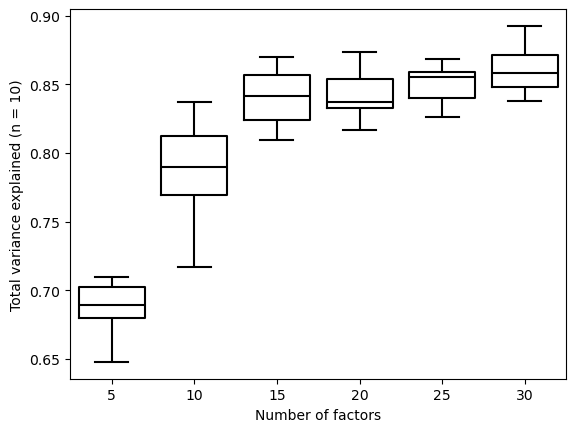

In [4]:
# compare variance explained across models
r2_df = pd.DataFrame()
for n_factors in [5, 10, 15, 20, 25, 30]:
    # get total variance explained for all 10 runs
    for run in range(10):
        model = mfl.MOFAFLEX.load('models/mofa_lr_n' + str(n_factors) + '_' + str(run))
        r2 = model.get_r2()['group_1'].sort_values('gene_expression', ascending = False).reset_index()
        r2_df = pd.concat([r2_df, pd.DataFrame({'n_factors': [n_factors], 
                                                'run': run,
                                                'total_variance_explained': [r2['gene_expression'].sum()]})])

# plot total variance explained
plt.figure()
sns.boxplot(r2_df, x = "n_factors", y = "total_variance_explained", fill = False, color = "black")
plt.xlabel("Number of factors")
plt.ylabel("Total variance explained (n = 10)")
plt.savefig('figures/total_var_explained_box.pdf', bbox_inches="tight")
plt.show()

## Analysis of selected model (with 15 factors)

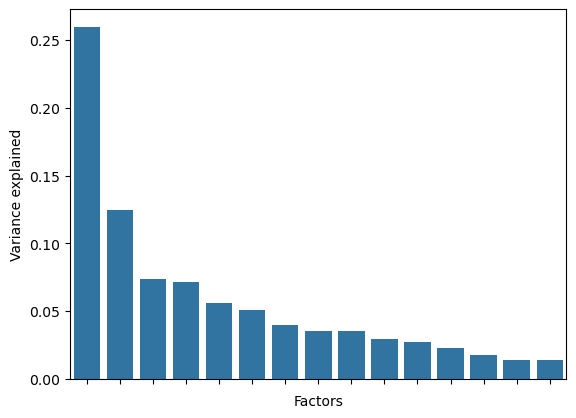

In [5]:
# load selected mofa model (run with highest var explained) and save loadings and factor values
model = mfl.MOFAFLEX.load('models/mofa_lr_n15_9')
model.get_weights()['gene_expression'].to_csv('data/MOFA_factors_perturbations.csv')
model.get_factors()['group_1'].to_csv('data/MOFA_factors_downstream_genes.csv') 

# plot the variance explained per factor
r2 = model.get_r2()['group_1'].sort_values('gene_expression', ascending = False).reset_index()
plt.figure()
ax = sns.barplot(r2, x = "index", y = "gene_expression")
ax.set_xticklabels([]) 
ax.set_xlabel("Factors")
ax.set_ylabel("Variance explained")
plt.savefig('figures/var_explained_n15.png', dpi = 300, bbox_inches="tight")
plt.show()

factor_order = r2['index'].to_list()

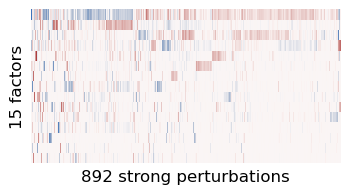

In [6]:
# which perturbations have similar factor values? 
Z = model.get_factors()['group_1'].T
# cluster columns
link = linkage(pdist(Z.T), method="average")
perturbation_order = leaves_list(link)
Z_ord = Z.iloc[:, perturbation_order]
Z_ord = Z_ord.loc[factor_order, :]

# plot ordered heatmap
plt.figure(figsize = (4,2))
hm = sns.heatmap(Z_ord, cmap="vlag", center=0, vmin = -3, vmax = 3, cbar = False,
            xticklabels = False, yticklabels = False)
hm.collections[0].set_rasterized(True)
plt.xlabel("892 strong perturbations", fontsize = 12)
plt.ylabel("15 factors", fontsize = 12)
plt.savefig('figures/MOFA_Z_clusters_n15.pdf', dpi = 300, bbox_inches="tight")
plt.show()

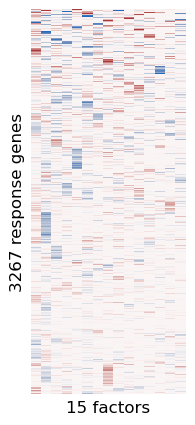

In [7]:
# which response genes have similar factor values? 
W = model.get_weights()['gene_expression'].T
# cluster rows
link = linkage(pdist(W), method="average")
res_gene_order = leaves_list(link)
W_ord = W.iloc[res_gene_order, :]
W_ord = W_ord.loc[:, factor_order]

# plot ordered heatmap
plt.figure(figsize = (2,5))
hm = sns.heatmap(W_ord, cmap="vlag", center=0, vmin = -3, vmax = 3, cbar = False,
            xticklabels = False, yticklabels = False)
hm.collections[0].set_rasterized(True)
plt.xlabel("15 factors", fontsize = 12)
plt.ylabel("3267 response genes", fontsize = 12)
plt.savefig('figures/MOFA_W_clusters_n15.pdf', dpi = 300, bbox_inches="tight")
plt.show()

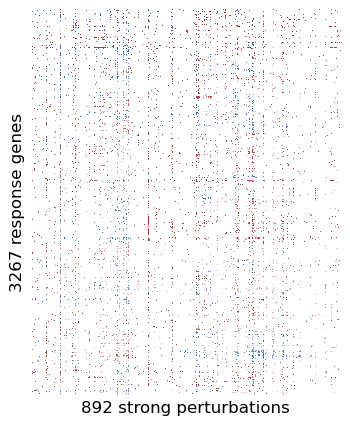

In [8]:
# plot LFC input in same order as W and Z for a MOFA overview figure
lfcs_wide = lfcs.pivot(index="contrast", columns="variable", values="log_fc")
lfcs_wide_ord = lfcs_wide.T.iloc[res_gene_order, perturbation_order]
plt.figure(figsize=(4, 5))
hm = sns.heatmap(lfcs_wide_ord, cmap="vlag", center=0, vmax = 0.5, vmin = -0.5, cbar = False, 
            xticklabels = False, yticklabels = False)
hm.collections[0].set_rasterized(True)
plt.xlabel("892 strong perturbations", fontsize = 12)
plt.ylabel("3267 response genes", fontsize = 12)
plt.savefig('figures/LFCs_ordered.pdf', dpi = 300, bbox_inches="tight")
plt.show()

## Which genes and pathways are included in each factor? 

In [9]:
# plot top genes
def top_abs_genes(series, n=10):
    df = (
        series
        .to_frame(name="value")
        .assign(abs_value=lambda x: x["value"].abs())
        .sort_values("abs_value", ascending=False)
        .head(n)
    )
    df["sign"] = np.where(df["value"] >= 0, "positive", "negative")
    return df

palette = {
    "positive": "#d62728",  # red
    "negative": "#1f77b4"   # blue
}

for f in range(15):
    factor = f"Factor {f + 1}"
    print(factor)

    # get perturbed and downstream genes with highest absolute values in each factor
    downstream_genes = model.get_weights()['gene_expression'].T[factor]
    perturbed_genes  = model.get_factors()['group_1'][factor]
    df_down = top_abs_genes(downstream_genes, n=15)
    df_pert = top_abs_genes(perturbed_genes,  n=15)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Perturbations
    sns.barplot(data=df_pert, x="abs_value", y=df_pert.index, hue="sign",
                palette=palette, dodge=False, ax=axes[0])
    axes[0].set_title("Perturbations")
    axes[0].set_xlabel("|Factor loading|")
    axes[0].set_ylabel("")
    axes[0].legend_.remove()

    # Downstream genes
    sns.barplot(data=df_down, x="abs_value", y=df_down.index, hue="sign",
                palette=palette, dodge=False, ax=axes[1])
    axes[1].set_title("Response genes")
    axes[1].set_xlabel("|Factor loading|")
    axes[1].set_ylabel("")
    axes[1].legend_.remove()

    fig.suptitle(factor, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"figures/MOFA_{factor}_top_abs_genes.pdf", dpi=300, bbox_inches="tight")
    plt.close()

Factor 1
Factor 2
Factor 3
Factor 4
Factor 5
Factor 6
Factor 7
Factor 8
Factor 9
Factor 10
Factor 11
Factor 12
Factor 13
Factor 14
Factor 15


In [10]:
# enriched pathways per factors (based on the top 10% genes)
def wrap_term(s, width=30):
    return "\n".join(textwrap.wrap(s, width))

gene_sets = [
    'MSigDB_Hallmark_2020',
    'Reactome_2022',
    'KEGG_2021_Human',
    'GO_Biological_Process_2025'
]

for f in factor_order[1:15]:
    factor = f
    print(factor)

    downstream_genes = model.get_weights()['gene_expression'].T[factor]
    perturbed_genes  = model.get_factors()['group_1'][factor]

    results = {}  # store results for plotting

    for genes, name in zip(
        [perturbed_genes, downstream_genes],
        ['Perturbations', 'Downstream genes']
    ):
        # select 10% with highest absolute values 
        abs_genes = genes.abs()
        cutoff = np.quantile(abs_genes, 0.9)
        top_genes = abs_genes[abs_genes >= cutoff].index.tolist()
        all_genes = abs_genes.index

        # run enrichment analyses
        enr = gp.enrichr(
            gene_list=top_genes,
            gene_sets=gene_sets,
            organism='Human',
            background=all_genes,
            outdir=None
        )  

        # Select up to 5 most significant pathways with adjusted p-value < 0.05
        res_df = enr.results
        res_df['Adjusted P-value'] = pd.to_numeric( res_df['Adjusted P-value'], errors='coerce' ) 
        res_df = res_df.sort_values('Adjusted P-value').drop_duplicates(subset='Term', keep='first')
        res_df = res_df[res_df['Adjusted P-value'] < 0.05]
        res_df = res_df.sort_values('Adjusted P-value').head(5)
        res_df['Term_wrapped'] = res_df['Term'].apply(wrap_term)
        res_df['-log10_adj_p'] = -np.log10(res_df['Adjusted P-value'])
        results[name] = res_df

    # plot the results
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=False)

    for ax, (name, df) in zip(axes, results.items()):
        if df.empty:
            ax.axis('off')
            ax.set_title(f"{name}\n(no significant terms)")
            continue

        sns.barplot(data=df, x='-log10_adj_p', y='Term_wrapped', ax=ax, color='gray')
        ax.set_title(name)
        ax.set_xlabel('-log10(adjusted p-value)')
        ax.set_ylabel('')

    fig.suptitle(factor, fontsize=14)
    plt.tight_layout()
    plt.savefig(
        f'figures/MOFA_enrichr_{factor}_both.pdf',
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

Factor 2
Factor 15
Factor 4
Factor 9
Factor 10
Factor 1
Factor 8
Factor 13
Factor 11
Factor 12
Factor 5
Factor 14
Factor 7
Factor 6


## Clustering of perturbations based on the factor values

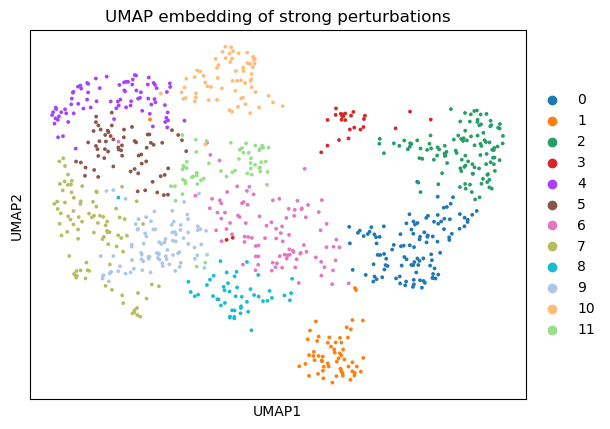

In [11]:
# plot UMAP of the perturbation embedding
adata = ad.AnnData(lfcs_wide)
adata.obsm['MOFA'] = model.get_factors()['group_1']
sc.pp.neighbors(adata, use_rep = "MOFA" , random_state=42)
sc.tl.leiden(adata, flavor="igraph", random_state=42)
sc.tl.umap(adata, random_state=42, min_dist = 0.3)
sc.pl.umap(adata, color="leiden", size=30, save = "_MOFA_perturbations.pdf", 
           title = "UMAP embedding of strong perturbations")

# save clustering results
adata.obs['leiden'].to_csv("data/MOFA_Leiden_clusters.csv")